In [1]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
warnings.filterwarnings("ignore")

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

RESULTS_DIR = "../results/metrics"
MODELS_DIR  = "../models"
FIGS_DIR    = "../results/figures"
os.makedirs(MODELS_DIR, exist_ok=True)

WINDOW       = 20
FEATURE_COLS = ['cap_Ah', 'v_mean', 'v_min', 'v_slope', 'i_mean',
                't_mean', 't_max', 'energy_Wh', 'duration_min',
                'soc_start', 'soc_end', 'EFC_norm']
FEAT_SHORT   = ['cap', 'v_μ', 'v_min', 'v_slope', 'i_μ',
                't_μ', 't_max', 'energy', 'dur', 'soc_s', 'soc_e', 'EFC_n']
N_FEATURES   = len(FEATURE_COLS)
print(f"Features ({N_FEATURES}): {FEATURE_COLS}")

Device: mps
Features (12): ['cap_Ah', 'v_mean', 'v_min', 'v_slope', 'i_mean', 't_mean', 't_max', 'energy_Wh', 'duration_min', 'soc_start', 'soc_end', 'EFC_norm']


In [2]:
with open(f"{RESULTS_DIR}/scaler_X.pkl", "rb") as f: scaler_X = pickle.load(f)
with open(f"{RESULTS_DIR}/scaler_y.pkl", "rb") as f: scaler_y = pickle.load(f)

df_all = pd.read_parquet(f"{RESULTS_DIR}/lab_cycles_labeled.parquet")
print(f"Cycles: {len(df_all):,}  |  Cells: {df_all['cell_id'].nunique()}")
for s in ["train","val","test"]:
    n = df_all[df_all["split"]==s]["cell_id"].nunique()
    print(f"  {s:5s}: {n} cells")

Cycles: 213,995  |  Cells: 206
  train: 154 cells
  val  : 26 cells
  test : 26 cells


In [3]:
class LabBatteryDataset(Dataset):
    def __init__(self, df, scaler_X, scaler_y,
                 window=WINDOW, feature_cols=FEATURE_COLS, stride=10):
        self.samples = []
        for cell_id, grp in df.groupby("cell_id"):
            grp  = grp.sort_values("EFC").reset_index(drop=True)
            X    = scaler_X.transform(grp[feature_cols].values).astype(np.float32)
            y    = scaler_y.transform(grp[["RUL"]].values).flatten().astype(np.float32)
            efcn = grp["EFC_norm"].values.astype(np.float32)
            for i in range(window, len(grp), stride):
                self.samples.append((
                    torch.tensor(X[i-window:i]),
                    torch.tensor(y[i]),
                    torch.tensor(efcn[i])
                ))
    def __len__(self):           return len(self.samples)
    def __getitem__(self, idx):  return self.samples[idx]

train_ds = LabBatteryDataset(df_all[df_all["split"]=="train"], scaler_X, scaler_y)
val_ds   = LabBatteryDataset(df_all[df_all["split"]=="val"],   scaler_X, scaler_y)
test_ds  = LabBatteryDataset(df_all[df_all["split"]=="test"],  scaler_X, scaler_y)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0)
print(f"Train:{len(train_ds):,}  Val:{len(val_ds):,}  Test:{len(test_ds):,}")

Train:15,798  Val:2,955  Test:2,329


In [4]:
class HyperPILSTM(nn.Module):
    """
    Physics-Informed LSTM with HyperNetwork-conditioned input projection.

    Key Innovation:
        A HyperNetwork (small MLP) takes EFC_norm (battery age 0→1) and
        generates a unique input projection matrix W_in [12×64] per sample.
        The LSTM literally uses different feature weights at each life stage:
          EFC_norm ≈ 0.1  →  W focuses on v_slope, cap_Ah  (SEI growth)
          EFC_norm ≈ 0.9  →  W focuses on v_min, energy    (knee point)

    Reference: Ha et al., HyperNetworks, ICLR 2017.
    """
    def __init__(self, input_size=12, hidden_size=64,
                 num_layers=2, dropout=0.4,
                 hyper_hidden=32, fc_dims=[32, 16]):
        super().__init__()
        self.input_size  = input_size
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # ── HyperNetwork: EFC_norm → W_in ───────────────────────────
        self.hypernet = nn.Sequential(
            nn.Linear(1, hyper_hidden),
            nn.ReLU(),
            nn.Linear(hyper_hidden, input_size * hidden_size)  # → [12×64]
        )

        # LayerNorm stabilises training (W values vary across ages)
        self.proj_norm = nn.LayerNorm(hidden_size)

        # Physics-informed warm-start (same as NB03)
        self.h0_embed = nn.Sequential(nn.Linear(1, hidden_size), nn.Tanh())

        # LSTM receives 64-dim projected features (not raw 12-dim)
        self.lstm = nn.LSTM(
            input_size  = hidden_size,   # ← 64 after projection
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0.0,
            batch_first = True
        )

        # RUL regression head
        layers, in_dim = [], hidden_size
        for out_dim in fc_dims:
            layers += [nn.Linear(in_dim, out_dim), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = out_dim
        layers += [nn.Linear(in_dim, 1)]
        self.fc = nn.Sequential(*layers)

    def _project(self, x, efc_norm):
        """Age-conditioned input projection: [B,20,12] → [B,20,64]."""
        B = x.size(0)
        W = self.hypernet(efc_norm.unsqueeze(-1))          # [B, 768]
        W = W.view(B, self.input_size, self.hidden_size)   # [B, 12, 64]
        return self.proj_norm(torch.bmm(x, W))             # [B, 20, 64]

    def get_embedding(self, x, efc_norm):
        """Returns h_T [B, 64] — used by NB07 for adversarial alignment."""
        x_proj = self._project(x, efc_norm)
        h0 = self.h0_embed(efc_norm.unsqueeze(-1))
        h0 = h0.unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(x_proj, (h0, c0))
        return out[:, -1, :]

    def forward(self, x, efc_norm):
        return self.fc(self.get_embedding(x, efc_norm)).squeeze(-1)

    def get_projection_weights(self, efc_norm_val):
        """Returns W_in [12, 64] for a given EFC_norm — for paper figure."""
        self.eval()
        with torch.no_grad():
            efcn = torch.tensor([[efc_norm_val]], dtype=torch.float32
                                ).to(next(self.parameters()).device)
            W = self.hypernet(efcn)
            return W.view(self.input_size, self.hidden_size).cpu().numpy()

    def get_feature_importance(self, efc_norm_val):
        """L2 norm of each W_in row = feature importance at given age."""
        W = self.get_projection_weights(efc_norm_val)
        return np.linalg.norm(W, axis=1)   # [12]


model = HyperPILSTM(input_size=12, hidden_size=64, num_layers=2,
                    dropout=0.4, hyper_hidden=32, fc_dims=[32, 16]).to(device)

total_p    = sum(p.numel() for p in model.parameters())
hyper_p    = sum(p.numel() for p in model.hypernet.parameters())
print(f"HyperPILSTM ready  |  Total: {total_p:,}  "
      f"(HyperNet: {hyper_p:,} → generates {12*64} weights per sample)")
print(f"vs baseline PI-LSTM: 56,001 params (+{total_p-56001:,})")

HyperPILSTM ready  |  Total: 94,849  (HyperNet: 25,408 → generates 768 weights per sample)
vs baseline PI-LSTM: 56,001 params (+38,848)


In [5]:
def weighted_mae_loss(preds, targets, efc_norm):
    w = torch.where(efc_norm < 0.4,
                    torch.full_like(efc_norm, 1.5),
                    torch.ones_like(efc_norm))
    return (w * torch.abs(preds - targets)).mean()

def monotonicity_loss(preds):
    if len(preds) < 2: return torch.tensor(0.0, device=preds.device)
    return torch.relu(preds[1:] - preds[:-1]).mean()

def capacity_physics_loss(preds, soh_proxy):
    if len(preds) < 2: return torch.tensor(0.0, device=preds.device)
    soh_diff = soh_proxy[1:] - soh_proxy[:-1]
    rul_diff = preds[1:]     - preds[:-1]
    return torch.relu(-rul_diff * torch.sign(soh_diff + 1e-8)).mean()

In [6]:
LR = 5e-4; EPOCHS = 80; PATIENCE = 20
LAMBDA_MONO = 0.05; LAMBDA_CAP = 0.02

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=4, factor=0.5)

history    = {"train_loss": [], "val_loss": [], "val_mae": []}
best_val   = float("inf"); patience_c = 0

print(f"{'='*60}\nTraining HyperPILSTM — {EPOCHS} epochs\n{'='*60}\n")

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for xb, yb, efcn in train_loader:
        xb, yb, efcn = xb.to(device), yb.to(device), efcn.to(device)
        optimizer.zero_grad()
        preds = model(xb, efcn)
        loss  = (weighted_mae_loss(preds, yb, efcn)
                 + LAMBDA_MONO * monotonicity_loss(preds)
                 + LAMBDA_CAP  * capacity_physics_loss(preds, xb[:,-1,0]))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += weighted_mae_loss(preds, yb, efcn).item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss, all_preds, all_true = 0.0, [], []
    with torch.no_grad():
        for xb, yb, efcn in val_loader:
            xb, yb, efcn = xb.to(device), yb.to(device), efcn.to(device)
            preds      = model(xb, efcn)
            val_loss  += weighted_mae_loss(preds, yb, efcn).item()
            all_preds.extend(preds.cpu().numpy())
            all_true.extend(yb.cpu().numpy())
    val_loss /= len(val_loader)
    p_inv = scaler_y.inverse_transform(
                np.array(all_preds).reshape(-1,1)).flatten()
    t_inv = scaler_y.inverse_transform(
                np.array(all_true).reshape(-1,1)).flatten()
    val_mae = mean_absolute_error(t_inv, p_inv)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_mae"].append(val_mae)
    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val, patience_c = val_loss, 0
        torch.save(model.state_dict(), f"{MODELS_DIR}/best_hyperpilstm.pt")
    else:
        patience_c += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | train={train_loss:.4f} | "
              f"val={val_loss:.4f} | MAE={val_mae*100:.1f}% | "
              f"patience={patience_c}/{PATIENCE}")
    if patience_c >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}"); break

print(f"\nBest val loss: {best_val:.4f}")

Training HyperPILSTM — 80 epochs

Epoch   1/80 | train=0.5002 | val=0.1976 | MAE=5.3% | patience=0/20
Epoch   5/80 | train=0.3021 | val=0.1582 | MAE=4.3% | patience=1/20
Epoch  10/80 | train=0.2837 | val=0.1328 | MAE=3.7% | patience=6/20
Epoch  15/80 | train=0.2829 | val=0.1357 | MAE=3.8% | patience=3/20
Epoch  20/80 | train=0.2804 | val=0.0937 | MAE=2.7% | patience=0/20
Epoch  25/80 | train=0.2777 | val=0.1350 | MAE=3.8% | patience=5/20
Epoch  30/80 | train=0.2731 | val=0.1106 | MAE=3.0% | patience=10/20
Epoch  35/80 | train=0.2722 | val=0.1153 | MAE=3.2% | patience=15/20
Epoch  40/80 | train=0.2740 | val=0.1171 | MAE=3.3% | patience=20/20

Early stopping at epoch 40

Best val loss: 0.0937


In [7]:
model.load_state_dict(
    torch.load(f"{MODELS_DIR}/best_hyperpilstm.pt", map_location=device))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb, efcn in test_loader:
        xb, efcn = xb.to(device), efcn.to(device)
        all_preds.extend(model(xb, efcn).cpu().numpy())
        all_true.extend(yb.numpy())

p_rel = np.clip(scaler_y.inverse_transform(
            np.array(all_preds).reshape(-1,1)).flatten(), 0, 1)
t_rel = np.clip(scaler_y.inverse_transform(
            np.array(all_true).reshape(-1,1)).flatten(), 0, 1)

mae  = mean_absolute_error(t_rel, p_rel)
rmse = np.sqrt(mean_squared_error(t_rel, p_rel))
r2   = r2_score(t_rel, p_rel)

print("=" * 55)
print("TEST RESULTS — HyperPILSTM")
print("=" * 55)
print(f"  MAE  : {mae:.4f}  ({mae*100:.1f}% of remaining life)")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")
print("\n  vs NB03 PI-LSTM baseline:")
print("  MAE=0.0216 (2.2%) | RMSE=0.0254 | R²=0.9939")
print("=" * 55)

TEST RESULTS — HyperPILSTM
  MAE  : 0.0288  (2.9% of remaining life)
  RMSE : 0.0342
  R²   : 0.9889

  vs NB03 PI-LSTM baseline:
  MAE=0.0216 (2.2%) | RMSE=0.0254 | R²=0.9939


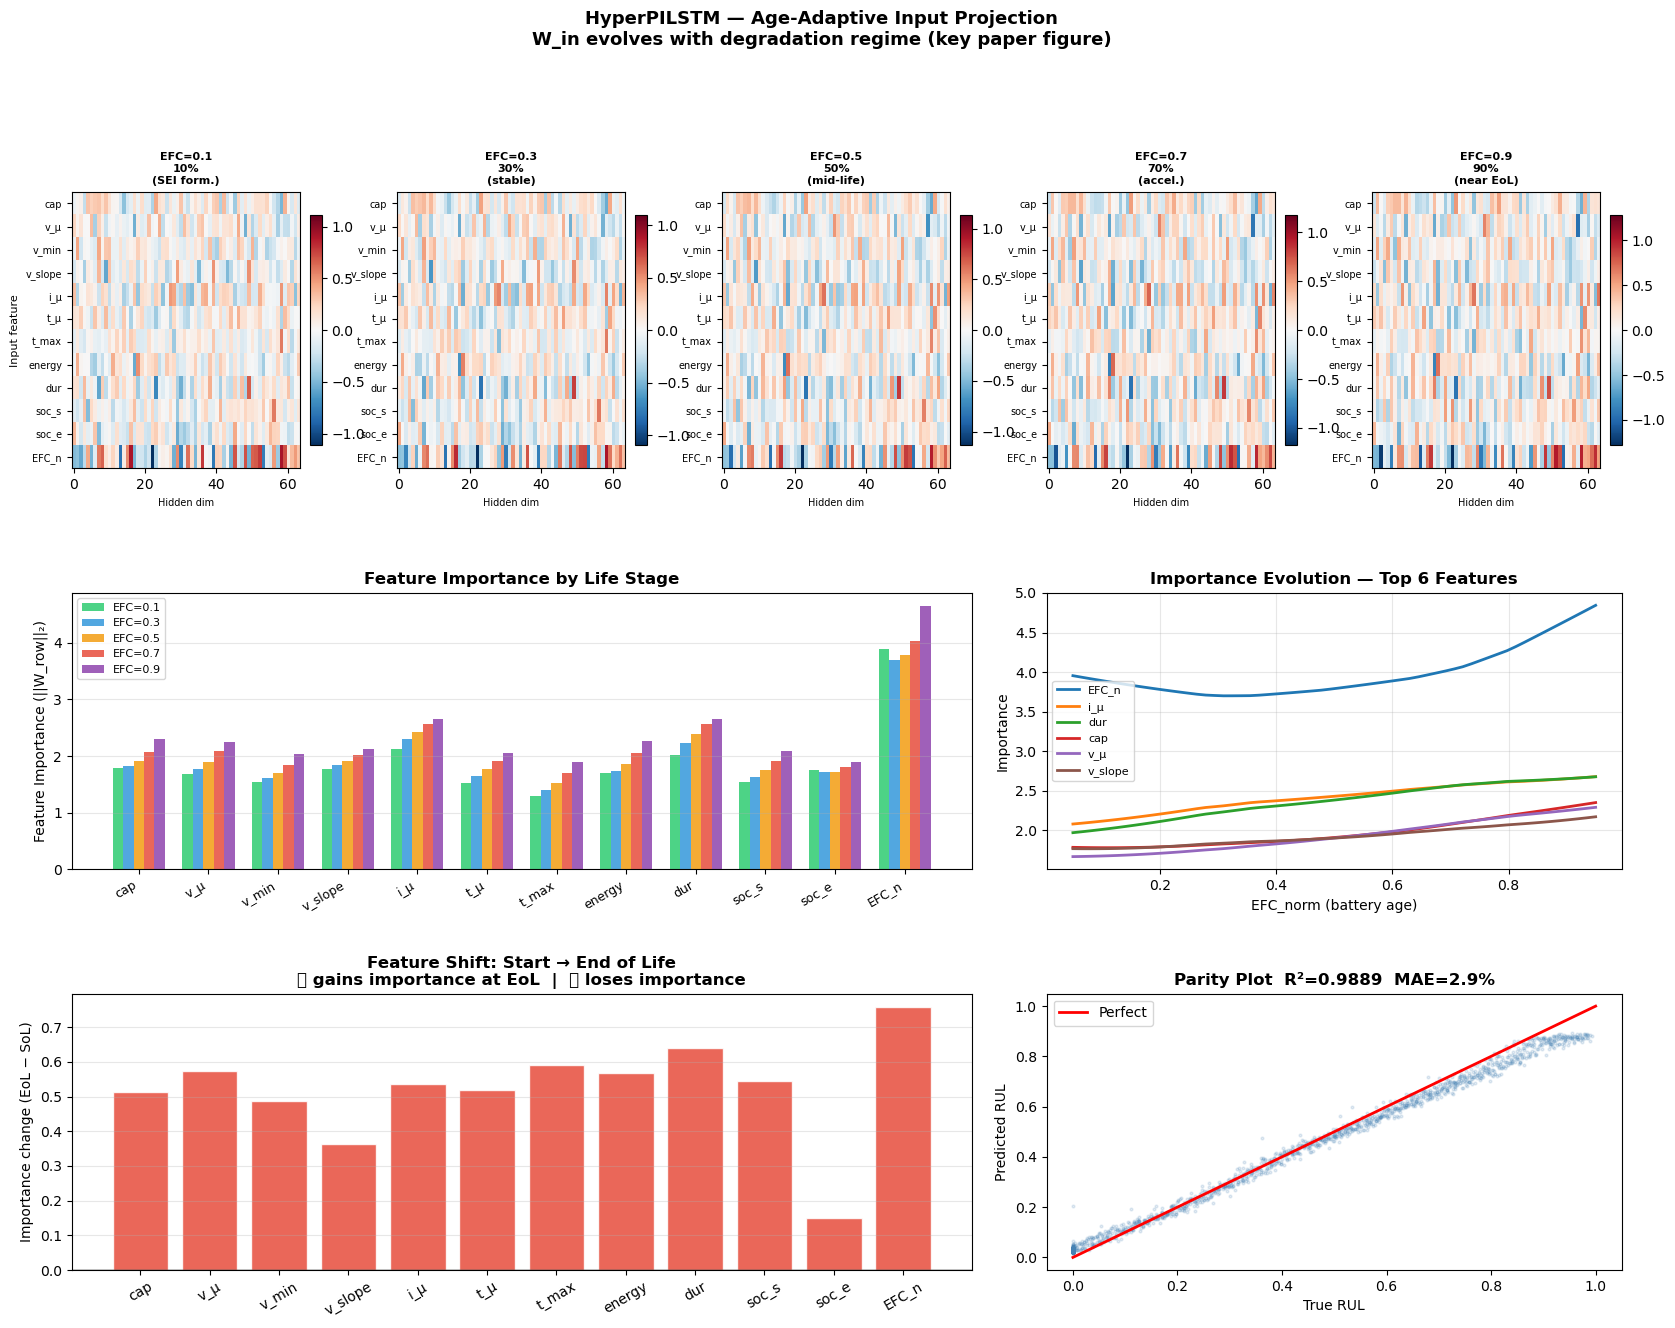

⭐ Key paper figure saved.


In [8]:
EFC_STAGES  = [0.1, 0.3, 0.5, 0.7, 0.9]
STAGE_NAMES = ["10%\n(SEI form.)", "30%\n(stable)",
               "50%\n(mid-life)", "70%\n(accel.)", "90%\n(near EoL)"]
COLORS      = ["#2ecc71","#3498db","#f39c12","#e74c3c","#8e44ad"]

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 5, figure=fig, hspace=0.45, wspace=0.3)

# Row 1: W_in heatmaps at 5 life stages
W_matrices = []
for col, (efc_val, name) in enumerate(zip(EFC_STAGES, STAGE_NAMES)):
    W = model.get_projection_weights(efc_val)
    W_matrices.append(W)
    vmax = max(abs(W.min()), abs(W.max()))
    ax   = fig.add_subplot(gs[0, col])
    im   = ax.imshow(W, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"EFC={efc_val}\n{name}", fontsize=8, fontweight="bold")
    ax.set_yticks(range(12))
    ax.set_yticklabels(FEAT_SHORT, fontsize=7)
    ax.set_xlabel("Hidden dim", fontsize=7)
    if col == 0: ax.set_ylabel("Input feature", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Row 2 left: Feature importance bar chart at all 5 stages
ax_bar = fig.add_subplot(gs[1, :3])
x_pos  = np.arange(N_FEATURES); width = 0.15
for i, (efc_val, color) in enumerate(zip(EFC_STAGES, COLORS)):
    imp = model.get_feature_importance(efc_val)
    ax_bar.bar(x_pos + i*width, imp, width,
               label=f"EFC={efc_val}", color=color, alpha=0.85)
ax_bar.set_xticks(x_pos + width*2)
ax_bar.set_xticklabels(FEAT_SHORT, rotation=30, ha="right", fontsize=9)
ax_bar.set_ylabel("Feature Importance (||W_row||₂)")
ax_bar.set_title("Feature Importance by Life Stage", fontweight="bold")
ax_bar.legend(fontsize=8); ax_bar.grid(axis="y", alpha=0.3)

# Row 2 right: Smooth importance evolution (top 6 features)
ax_evo     = fig.add_subplot(gs[1, 3:])
efc_range  = np.linspace(0.05, 0.95, 60)
imp_curves = np.array([model.get_feature_importance(e) for e in efc_range])
top6       = np.argsort(imp_curves.mean(0))[-6:][::-1]
for rank, fidx in enumerate(top6):
    ax_evo.plot(efc_range, imp_curves[:, fidx],
                label=FEAT_SHORT[fidx],
                color=cm.get_cmap("tab10")(rank), lw=2)
ax_evo.set_xlabel("EFC_norm (battery age)"); ax_evo.set_ylabel("Importance")
ax_evo.set_title("Importance Evolution — Top 6 Features", fontweight="bold")
ax_evo.legend(fontsize=8); ax_evo.grid(alpha=0.3)

# Row 3 left: EoL − SoL difference
ax_diff  = fig.add_subplot(gs[2, :3])
W_diff   = model.get_feature_importance(0.9) - model.get_feature_importance(0.1)
c_diff   = ["#e74c3c" if d > 0 else "#3498db" for d in W_diff]
ax_diff.bar(FEAT_SHORT, W_diff, color=c_diff, alpha=0.85, edgecolor="white")
ax_diff.axhline(0, color="black", lw=1)
ax_diff.set_ylabel("Importance change (EoL − SoL)")
ax_diff.set_title("Feature Shift: Start → End of Life\n"
                   "🔴 gains importance at EoL  |  🔵 loses importance",
                   fontweight="bold")
ax_diff.tick_params(axis="x", rotation=30); ax_diff.grid(axis="y", alpha=0.3)

# Row 3 right: Parity plot
ax_p = fig.add_subplot(gs[2, 3:])
ax_p.scatter(t_rel, p_rel, alpha=0.15, s=4, color="steelblue")
ax_p.plot([0,1],[0,1],"r-",lw=2,label="Perfect")
ax_p.set_xlabel("True RUL"); ax_p.set_ylabel("Predicted RUL")
ax_p.set_title(f"Parity Plot  R²={r2:.4f}  MAE={mae*100:.1f}%",
               fontweight="bold")
ax_p.legend(); ax_p.set_xlim(-0.05,1.05); ax_p.set_ylim(-0.05,1.05)

plt.suptitle("HyperPILSTM — Age-Adaptive Input Projection\n"
             "W_in evolves with degradation regime (key paper figure)",
             fontsize=13, fontweight="bold", y=1.01)
plt.savefig(f"{FIGS_DIR}/hyperpilstm_weight_evolution.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("⭐ Key paper figure saved.")

In [9]:
import shutil
# Overwrite best_pilstm_v2.pt so NB05/NB07 pick this up automatically
shutil.copy(f"{MODELS_DIR}/best_hyperpilstm.pt",
            f"{MODELS_DIR}/best_pilstm_v2.pt")
print("Saved best_hyper_pilstm_v2.pt ← NB05 will use this automatically")

Saved best_hyper_pilstm_v2.pt ← NB05 will use this automatically
